# Homework 4: Unsupervised Learning

Solutions to Exercises 1, 2, 3, 5 and 6 (the numbering follows the assignment sheet, which
jumps from Exercise 3 to Exercise 5). Each exercise contains the implementation, the requested
experiments and plots, and a written comment on the results.

**Data.** Exercise 3 uses the standard `cameraman` test image, bundled with `scikit-image`.
Exercises 5 and 6 use the Kaggle MNIST Digit Recognizer dataset:
https://www.kaggle.com/datasets/animatronbot/mnist-digit-recognizer. Download the training CSV
(42000 rows, 785 columns: `label` + 784 pixel values) and place it in the same folder as this
notebook; the loading cell in Exercise 5 finds it automatically.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3D projection)

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

---
## Exercise 1: Compute the SVD of a Matrix & Verify the Reconstruction

**1-2. Construct a non-square matrix and compute its SVD.**

In [2]:
rng = np.random.default_rng(0)

m, n = 10, 6
A = rng.normal(size=(m, n))
print("A shape:", A.shape)

U, S, Vt = np.linalg.svd(A, full_matrices=True)
print("U shape:", U.shape, " S shape:", S.shape, " Vt shape:", Vt.shape)

A shape: (10, 6)
U shape: (10, 10)  S shape: (6,)  Vt shape: (6, 6)


**3. Verify the reconstruction** $A \approx U\Sigma V^T$.

In [3]:
# Sigma is rectangular (m x n) with the singular values on the main diagonal.
# np.fill_diagonal works for any m, n, unlike slicing with a hard-coded index.
Sigma = np.zeros((m, n))
np.fill_diagonal(Sigma, S)

A_reconstructed = U @ Sigma @ Vt
recon_error = np.linalg.norm(A - A_reconstructed, ord='fro')
print(f"||A - U Sigma V^T||_F = {recon_error:.3e}")

||A - U Sigma V^T||_F = 7.189e-15


**4. Print and plot the singular values.**

Singular values: [4.82910775 3.4230114  2.53935329 2.01193915 1.37390916 1.12378003]


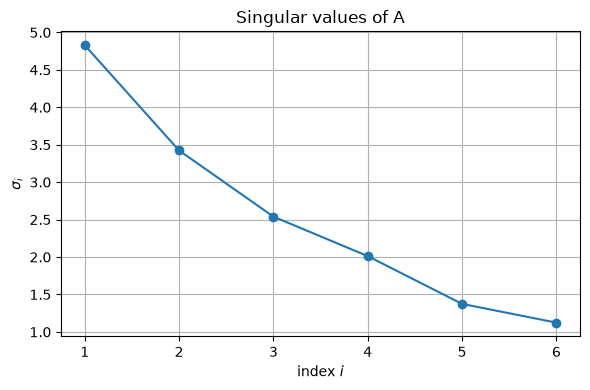

In [4]:
print("Singular values:", S)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(1, len(S) + 1), S, 'o-', color='tab:blue')
ax.set_xlabel('index $i$')
ax.set_ylabel(r'$\sigma_i$')
ax.set_title('Singular values of A')
plt.tight_layout()
plt.show()

To make the last point of the comment below *verifiable* rather than merely asserted, we also
build a matrix that is rank-deficient **by construction** and inspect its smallest singular value.

In [5]:
B = rng.normal(size=(10, 6))
B[:, 5] = B[:, 0] + 2 * B[:, 1]   # last column is an exact linear combination -> rank(B) = 5

S_B = np.linalg.svd(B, compute_uv=False)
print("Singular values of the rank-deficient B:")
print(S_B)
print(f"\nSmallest singular value: {S_B[-1]:.3e}  (mathematically it should be exactly 0)")
print(f"Machine epsilon: {np.finfo(float).eps:.3e}")

Singular values of the rank-deficient B:
[8.55656544e+00 4.47510217e+00 3.07683062e+00 2.65162692e+00
 1.40377068e+00 1.03756104e-15]

Smallest singular value: 1.038e-15  (mathematically it should be exactly 0)
Machine epsilon: 2.220e-16


**5. Comments.**

- **Why singular values appear in descending order.** This ordering is part of the definition of the
  SVD: $\sigma_1$ measures the energy of $A$ along the direction in which it is largest, $\sigma_2$
  the largest among the directions orthogonal to the first one, and so on. Sorting them this way is
  what makes truncation meaningful: keeping the first $k$ terms automatically keeps the $k$ *most
  important* rank-one components, rather than an arbitrary subset of them.

- **Why small singular values correspond to "less important" directions.** The rank-one components
  $\sigma_i u_i v_i^T$ are mutually orthogonal, and the total energy of the matrix splits across them
  as $\|A\|_F^2 = \sum_i \sigma_i^2$. A small $\sigma_i$ therefore means that its component
  contributes very little to that total, so discarding it changes $A$ only marginally in the
  least-squares sense measured by the Frobenius norm. This is exactly the mechanism exploited in
  Exercises 2 and 3.

- **Why floating-point arithmetic makes exact zeros rare.** Even when $A$ is mathematically
  rank-deficient, the algorithms used to compute the SVD (Householder reflections, QR iterations)
  perform thousands of floating-point operations, each introducing a rounding error of relative size
  $\approx \varepsilon_{\text{mach}} \approx 2.2\cdot 10^{-16}$. Those errors perturb the matrix
  slightly, so the singular values that should vanish come out as tiny but non-zero numbers instead.
  The cell above shows this concretely: `B` has rank 5 by construction, yet its sixth singular value
  is of the order of $10^{-16}$ rather than exactly `0.0`. In practice one therefore determines the
  numerical rank by counting the singular values above a tolerance, not by testing equality to zero.

---
## Exercise 2: Best Rank-$k$ Approximation

**1. Rank-$k$ approximation function.**

In [6]:
def rank_k_approx(U_, S_, Vt_, k):
    """Rank-k approximation A_k = sum_{i=1}^k sigma_i u_i v_i^T.

    Implemented as a matrix product, which is equivalent to the sum of outer
    products but much faster. The SVD factors are passed in so that they are
    computed only once by the caller.
    """
    if k == 0:
        return np.zeros((U_.shape[0], Vt_.shape[1]))
    return U_[:, :k] @ np.diag(S_[:k]) @ Vt_[:k, :]


# sanity check: the rank-min(m,n) approximation must coincide with A itself
A_full = rank_k_approx(U, S, Vt, min(m, n))
print("Sanity check, ||A - A_full||_F =", np.linalg.norm(A - A_full, ord='fro'))

Sanity check, ||A - A_full||_F = 7.18909138751788e-15


**2-3. Approximation error $E(k)=\|A-A_k\|_F$ vs $k$.**

Alongside $E(k)$ we print the theoretical value predicted by the Eckart-Young theorem,
$\sqrt{\sum_{i>k}\sigma_i^2}$, so that the optimality claim discussed below is numerically verified
rather than just stated.

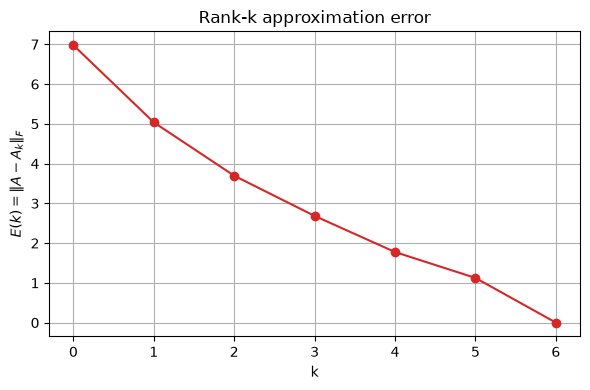

  k           E(k)   sqrt(sum sigma_i^2, i>k)
  0     6.9774e+00                 6.9774e+00
  1     5.0362e+00                 5.0362e+00
  2     3.6941e+00                 3.6941e+00
  3     2.6830e+00                 2.6830e+00
  4     1.7750e+00                 1.7750e+00
  5     1.1238e+00                 1.1238e+00
  6     7.1891e-15                 0.0000e+00


In [7]:
ks = np.arange(0, min(m, n) + 1)
errors = np.array([np.linalg.norm(A - rank_k_approx(U, S, Vt, k), ord='fro') for k in ks])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, errors, 'o-', color='tab:red')
ax.set_xlabel('k')
ax.set_ylabel(r'$E(k) = \|A - A_k\|_F$')
ax.set_title('Rank-k approximation error')
plt.tight_layout()
plt.show()

print(f"{'k':>3s} {'E(k)':>14s} {'sqrt(sum sigma_i^2, i>k)':>26s}")
for k in ks:
    print(f"{k:>3d} {errors[k]:>14.4e} {np.sqrt(np.sum(S[k:]**2)):>26.4e}")

**4. Why the SVD gives the optimal rank-$k$ approximation.**

The **Eckart-Young-Mirsky theorem** states that among *all* matrices $B$ with $\operatorname{rank}(B)\le k$,
the truncated SVD $A_k=\sum_{i=1}^k \sigma_i u_i v_i^T$ minimises $\|A-B\|_F$ (and also $\|A-B\|_2$),
and that the minimum error equals

$$E(k) = \Big(\sum_{i=k+1}^{\min(m,n)}\sigma_i^2\Big)^{1/2},$$

which is exactly what the two columns printed above confirm to machine precision.

The intuition is that the SVD decomposes $A$ into **mutually orthogonal** rank-one components, each
carrying energy $\sigma_i^2$, with the total satisfying $\|A\|_F^2=\sum_i\sigma_i^2$. Because of the
orthogonality, the energy is partitioned additively: whatever we discard contributes its $\sigma_i^2$
in full to the squared error, with no cross terms. Minimising the error over rank-$k$ matrices therefore
reduces to choosing which $k$ components to keep, and the best choice is trivially the $k$ largest
$\sigma_i$. No other set of $k$ directions -- whether taken from a different basis or as a different
subset of the singular directions -- can capture more energy with the same number of degrees of freedom.
This is precisely what justifies the use of SVD and PCA for compression and dimensionality reduction
in Exercises 3, 5 and 6.

---
## Exercise 3: Image Compression with SVD

**1. Load the `cameraman` image** ($512\times512$), the classic image-processing test image used in
the lecture notes, obtained here through `skimage.data.camera()`.

Image shape: (512, 512)  pixel range: 0.0 - 255.0


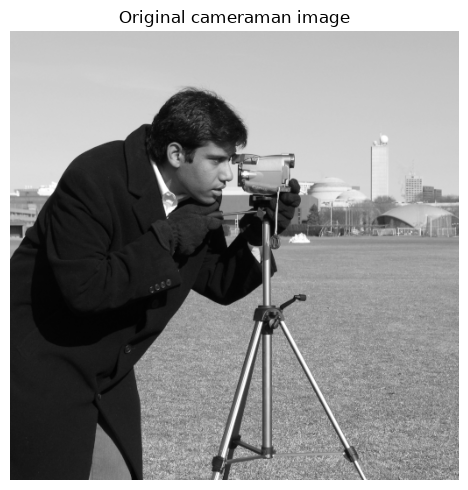

In [10]:
from skimage import data

X_img = data.camera().astype(float)
m_img, n_img = X_img.shape
print("Image shape:", X_img.shape, " pixel range:", X_img.min(), "-", X_img.max())

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(X_img, cmap='gray', vmin=0, vmax=255)
ax.set_title('Original cameraman image')
ax.axis('off')
plt.tight_layout()
plt.show()

**2. Compute its SVD.**

In [11]:
# full_matrices=False gives the reduced SVD, which is all we need and is cheaper.
# The SVD is computed ONCE here and reused for every value of k below.
U_img, S_img, Vt_img = np.linalg.svd(X_img, full_matrices=False)
print("U:", U_img.shape, " S:", S_img.shape, " Vt:", Vt_img.shape)

U: (512, 512)  S: (512,)  Vt: (512, 512)


**3. Rank-$k$ reconstructions, reconstruction error and compression factor** for
$k\in\{5,20,50,100,200\}$, with

$$c_k = 1 - \frac{k(m+n+1)}{mn}.$$

In [12]:
ks_img = [5, 20, 50, 100, 200]


def compression_factor(k, m_, n_):
    return 1 - (k * (m_ + n_ + 1)) / (m_ * n_)


reconstructions, errors_img, comp_factors = {}, {}, {}
for k in ks_img:
    Xk = rank_k_approx(U_img, S_img, Vt_img, k)
    reconstructions[k] = Xk
    errors_img[k] = np.linalg.norm(X_img - Xk, ord='fro')
    comp_factors[k] = compression_factor(k, m_img, n_img)
    print(f"k={k:>4d}:  error={errors_img[k]:>10.2f}   compression factor c_k={comp_factors[k]:.4f}")

k=   5:  error=  13086.87   compression factor c_k=0.9804
k=  20:  error=   7699.91   compression factor c_k=0.9218
k=  50:  error=   4836.07   compression factor c_k=0.8045
k= 100:  error=   2992.14   compression factor c_k=0.6090
k= 200:  error=   1342.36   compression factor c_k=0.2180


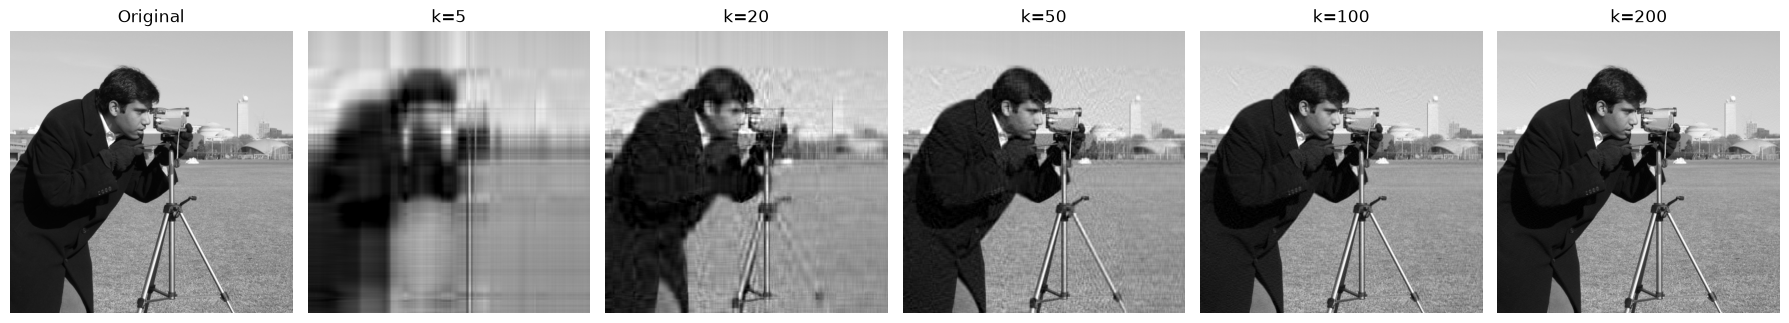

In [13]:
fig, axes = plt.subplots(1, len(ks_img) + 1, figsize=(3 * (len(ks_img) + 1), 3.2))

# vmin/vmax are fixed to the original grey range: without them matplotlib would
# rescale every panel independently and the visual comparison across k would be
# misleading (each reconstruction would get its own contrast).
axes[0].imshow(X_img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

for ax, k in zip(axes[1:], ks_img):
    ax.imshow(reconstructions[k], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'k={k}')
    ax.axis('off')

plt.tight_layout()
plt.show()

**Reconstruction error and compression factor vs $k$**, on a finer grid of $k$ for a smoother picture
(the five requested values are marked in black).

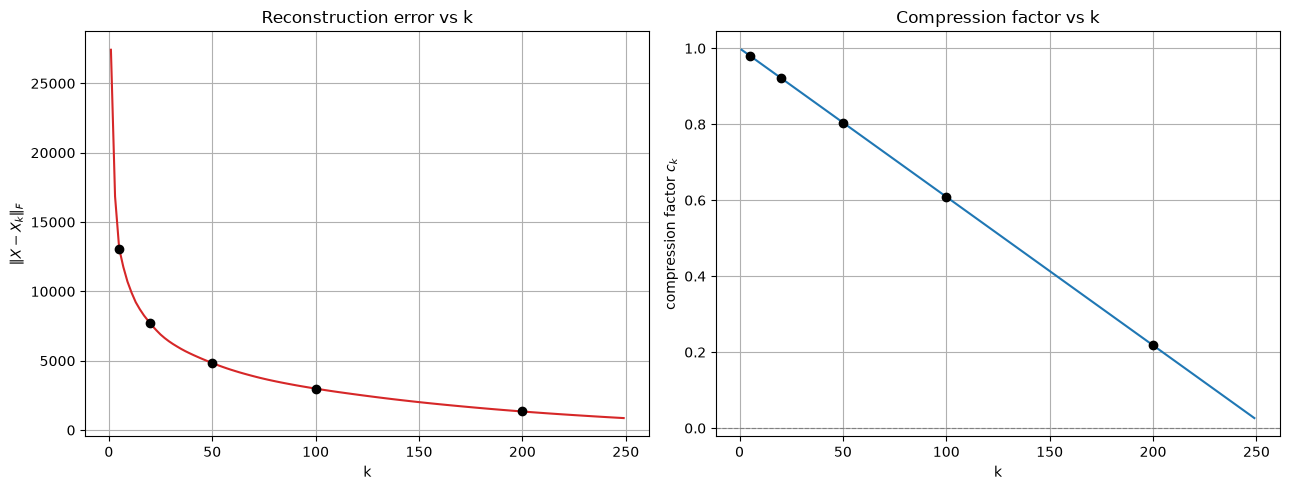

In [14]:
ks_fine = np.arange(1, 250, 2)
errors_fine = [np.linalg.norm(X_img - rank_k_approx(U_img, S_img, Vt_img, k), ord='fro') for k in ks_fine]
comp_fine = [compression_factor(k, m_img, n_img) for k in ks_fine]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ks_fine, errors_fine, color='tab:red')
axes[0].scatter(ks_img, [errors_img[k] for k in ks_img], color='black', zorder=5)
axes[0].set_xlabel('k')
axes[0].set_ylabel(r'$\|X - X_k\|_F$')
axes[0].set_title('Reconstruction error vs k')

axes[1].plot(ks_fine, comp_fine, color='tab:blue')
axes[1].scatter(ks_img, [comp_factors[k] for k in ks_img], color='black', zorder=5)
axes[1].axhline(0, color='gray', lw=0.8, ls='--')
axes[1].set_xlabel('k')
axes[1].set_ylabel(r'compression factor $c_k$')
axes[1].set_title('Compression factor vs k')

plt.tight_layout()
plt.show()

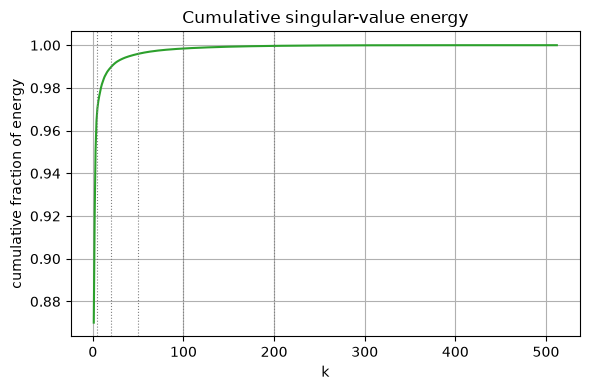

k=   5: cumulative energy fraction = 0.9704
k=  20: cumulative energy fraction = 0.9898
k=  50: cumulative energy fraction = 0.9960
k= 100: cumulative energy fraction = 0.9985
k= 200: cumulative energy fraction = 0.9997


In [15]:
# Where is the "energy" of the image concentrated?
energy = S_img ** 2
cumulative_energy = np.cumsum(energy) / np.sum(energy)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(1, len(S_img) + 1), cumulative_energy, color='tab:green')
for k in ks_img:
    ax.axvline(k, color='gray', ls=':', lw=0.8)
ax.set_xlabel('k')
ax.set_ylabel('cumulative fraction of energy')
ax.set_title('Cumulative singular-value energy')
plt.tight_layout()
plt.show()

for k in ks_img:
    print(f"k={k:>4d}: cumulative energy fraction = {cumulative_energy[k-1]:.4f}")

**4. Comments.**

- **How visual quality improves with $k$.** At $k=5$ the reconstruction is a blurry, low-frequency
  sketch: the large-scale structure (sky, coat, tripod, overall contrast) is recognisable, but every
  fine detail is gone. By $k=20$ the silhouette and the main edges are sharp; by $k=50$ the buildings
  in the background and the texture of the grass start to reappear; and at $k=200$ out of $512$ the
  result is visually almost indistinguishable from the original, even though more than half of the
  singular directions have been discarded.

- **Why most of the energy is contained in the first singular values.** Natural images are strongly
  **spatially correlated**: neighbouring pixels tend to have similar intensities and large regions
  share smooth gradients or repeated textures. Rows and columns of the pixel matrix are therefore far
  from independent, so the *effective* rank of $X$ is much lower than $\min(m,n)$. A handful of
  singular directions, capturing the dominant large-scale patterns of variation, already account for
  almost all of $\sum_i\sigma_i^2$; the cumulative-energy curve above makes this quantitative, with
  the first 5 components alone carrying about 97% of the energy and the first 50 about 99.6%. The
  remaining directions encode fine detail and noise, which are visually relevant but energetically
  negligible.

- **The trade-off between compression and fidelity.** Storing $U_{:,:k}$, $\sigma_{1:k}$ and
  $V^T_{:k,:}$ costs $k(m+n+1)$ numbers instead of $mn$, so the compression factor $c_k$ decreases
  linearly with $k$ while the reconstruction error also decreases, though much more slowly than
  linearly. Small $k$ means aggressive compression and poor fidelity; large $k$ means high fidelity
  and little gain. Note also that $c_k$ becomes negative for $k > mn/(m+n+1) \approx 255$: past that
  point the "compressed" representation is *larger* than the original, and the scheme is pointless.
  Because of the energy concentration described above, a sweet spot around $k\approx 50\!-\!100$
  retains most of the achievable quality while still discarding the large majority of the directions.

- **The connection between SVD and optimal low-rank approximation.** By the Eckart-Young theorem
  recalled in Exercise 2, for every fixed $k$ the truncated reconstruction $X_k$ is *provably* the
  closest rank-$k$ matrix to $X$ in Frobenius norm. The error/compression curves above are therefore
  not merely good: they are the **best achievable** trade-off for any rank-based compression scheme
  judged by this criterion, since no other rank-$k$ matrix can reach a lower reconstruction error at
  the same storage cost.

---
## Exercise 5: PCA + Clustering on a Real Dataset

**1. Load the CSV.** We use the Kaggle MNIST Digit Recognizer dataset
(https://www.kaggle.com/datasets/animatronbot/mnist-digit-recognizer). The training file has 42000
rows and 785 columns: one `label` column plus 784 pixel intensities in $[0,255]$, i.e. the $28\times28$
image flattened row by row. Place the CSV next to this notebook before running the cell below.

In [16]:
from pathlib import Path


def load_mnist_csv(path=None):
    """Load the Kaggle MNIST Digit Recognizer training CSV.

    Pass an explicit path if you know it; otherwise the function looks for a CSV in the
    current folder (and in a 'data'/'input' subfolder) that has a 'label' column and 785
    columns, which is the signature of the Kaggle training file.
    """
    if path is not None:
        return pd.read_csv(path)

    candidates = []
    for folder in [Path('.'), Path('data'), Path('input'), Path('digit-recognizer')]:
        if folder.is_dir():
            candidates += sorted(folder.glob('*.csv'))

    for c in candidates:
        head = pd.read_csv(c, nrows=1)
        if 'label' in head.columns and head.shape[1] == 785:
            print(f"Found the Kaggle training file: {c}")
            return pd.read_csv(c)

    raise FileNotFoundError(
        "Kaggle MNIST training CSV not found.\n"
        "Download it from https://www.kaggle.com/datasets/animatronbot/mnist-digit-recognizer\n"
        "and place it next to this notebook, or call load_mnist_csv('<path/to/file.csv>').\n"
        f"CSV files inspected: {[str(c) for c in candidates] or 'none'}"
    )


df_mnist = load_mnist_csv()

# sanity checks on the data we just loaded
assert 'label' in df_mnist.columns, "missing 'label' column"
assert df_mnist.shape[1] == 785, f"expected 785 columns, got {df_mnist.shape[1]}"
print("Full dataset:", df_mnist.shape)
print("Pixel range:", df_mnist.drop(columns='label').values.min(),
      "-", df_mnist.drop(columns='label').values.max())
print(df_mnist['label'].value_counts().sort_index())

Found the Kaggle training file: train.csv
Full dataset: (42000, 785)
Pixel range: 0 - 255
label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


**2. Filter the requested pair of digits and split into training and test sets.**

We wrap this in a function, since Exercises 5 and 6 both need it for several digit pairs. The
positive class (label `1`) is always the *second* digit passed to the function.

In [17]:
def load_digit_pair(df, digit0, digit1, test_frac=0.2, seed=0):
    """Filter two digit classes, encode digit1 as 1 and digit0 as 0, split into train/test."""
    sub = df[df['label'].isin([digit0, digit1])]
    X = sub.drop(columns='label').values.astype(float)
    y = (sub['label'].values == digit1).astype(int)

    rng_ = np.random.default_rng(seed)
    idx = rng_.permutation(len(X))
    n_test = int(len(X) * test_frac)
    test_idx, train_idx = idx[:n_test], idx[n_test:]
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]


X_train_34, y_train_34, X_test_34, y_test_34 = load_digit_pair(df_mnist, 3, 4, seed=5)
print(f"digits 3 vs 4 -> train: {X_train_34.shape}, test: {X_test_34.shape}")
print(f"class balance in train: {np.bincount(y_train_34)} (digit 3, digit 4)")

digits 3 vs 4 -> train: (6739, 784), test: (1684, 784)
class balance in train: [3470 3269] (digit 3, digit 4)


**3-4. Center the training data and compute the reduced SVD of the centered matrix.**

The test set is centered with the **training** centroid $c(X_{\text{train}})$, never with its own:
the projection must be a fixed transformation estimated on the training data only.

In [18]:
def pca_fit(X_train_, k):
    """Center X_train_, take its reduced SVD, return the mean, the projection matrix
    P = V_k (d x k, columns = principal directions) and the singular values."""
    mean_ = X_train_.mean(axis=0)
    Xc = X_train_ - mean_
    U_, S_, Vt_ = np.linalg.svd(Xc, full_matrices=False)
    P_ = Vt_[:k, :].T
    return mean_, P_, S_


def pca_project(X_, mean_, P_):
    """Project any data matrix using the TRAINING centroid and directions."""
    return (X_ - mean_) @ P_


# The SVD is computed once with k=3: the 2D projection of points 5-8 simply uses the
# first two columns of P, so the two views are guaranteed to be consistent.
mean_34, P3_34, S_34 = pca_fit(X_train_34, k=3)
P2_34 = P3_34[:, :2]
print("Top 5 singular values (3 vs 4):", S_34[:5])

Top 5 singular values (3 vs 4): [61053.89375472 39423.55143196 35526.84044906 33486.07968337
 30318.57692342]


**5-7. Project onto $k=2$ principal components and plot the training scatter coloured by label,
with the test set overlaid in the same figure.**

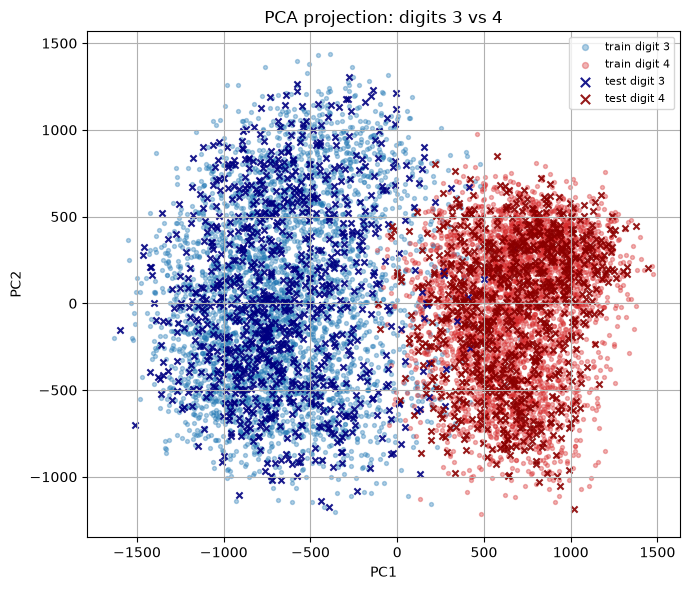

In [19]:
Z_train_34 = pca_project(X_train_34, mean_34, P2_34)
Z_test_34 = pca_project(X_test_34, mean_34, P2_34)

fig, ax = plt.subplots(figsize=(7, 6))
for cls, name, color in [(0, 'digit 3', 'tab:blue'), (1, 'digit 4', 'tab:red')]:
    mask = y_train_34 == cls
    ax.scatter(Z_train_34[mask, 0], Z_train_34[mask, 1], s=8, alpha=0.35, color=color,
               label=f'train {name}')
# the test points are coloured by their true label as well, so that the overlay is informative
for cls, name, color in [(0, 'digit 3', 'navy'), (1, 'digit 4', 'darkred')]:
    mask = y_test_34 == cls
    ax.scatter(Z_test_34[mask, 0], Z_test_34[mask, 1], s=20, alpha=0.9, color=color,
               marker='x', label=f'test {name}')

ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('PCA projection: digits 3 vs 4')
ax.legend(markerscale=1.5, fontsize=8)
plt.tight_layout()
plt.show()

**8. Repeat with digits 5 vs 8 and 1 vs 7, and compare.**

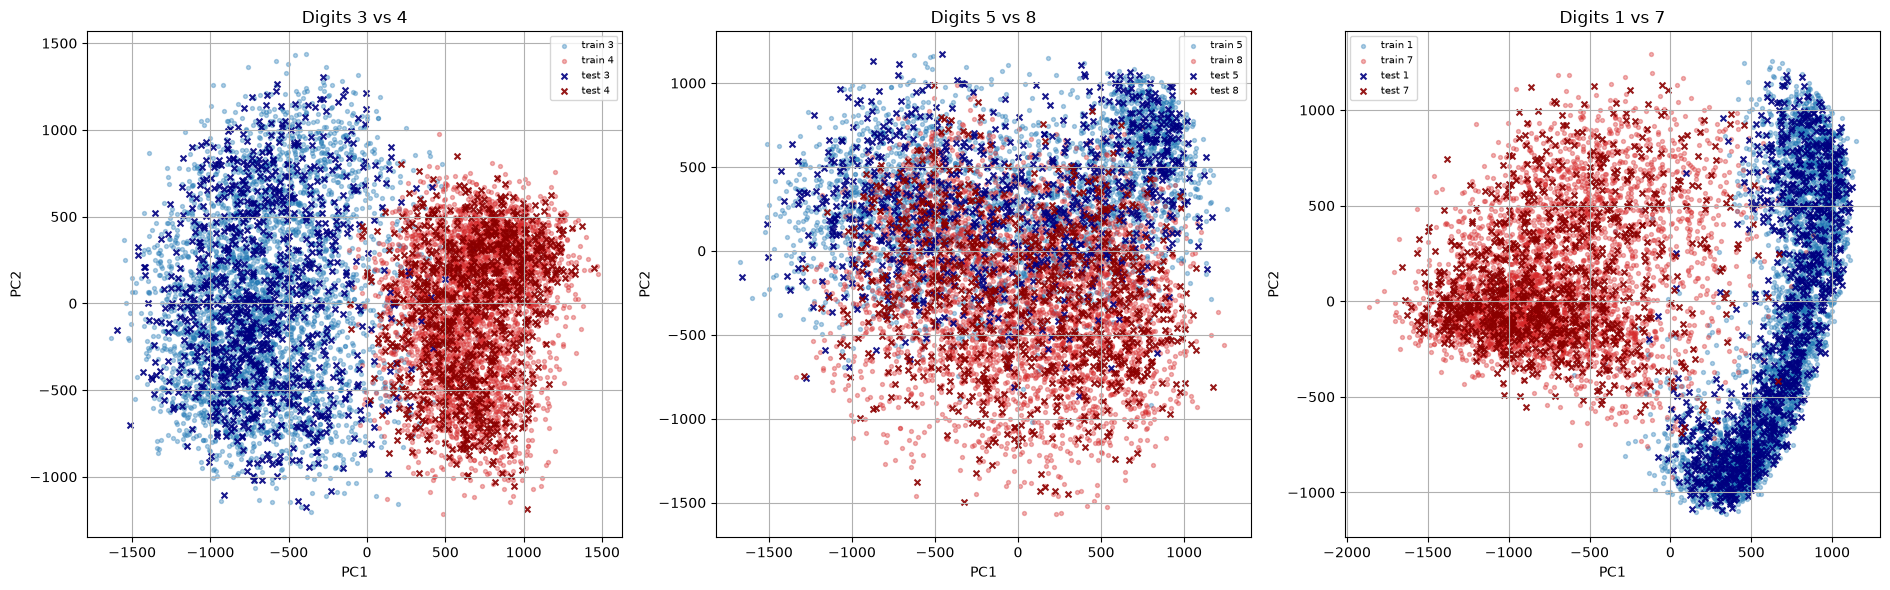

In [20]:
def pca_scatter(ax, df, digit0, digit1, seed=5):
    """Fit PCA on the train split of a digit pair and scatter train + test on the given axes."""
    Xtr, ytr, Xte, yte = load_digit_pair(df, digit0, digit1, seed=seed)
    mean_, P_, _ = pca_fit(Xtr, k=2)
    Ztr, Zte = pca_project(Xtr, mean_, P_), pca_project(Xte, mean_, P_)

    for cls, d, color in [(0, digit0, 'tab:blue'), (1, digit1, 'tab:red')]:
        mask = ytr == cls
        ax.scatter(Ztr[mask, 0], Ztr[mask, 1], s=8, alpha=0.35, color=color, label=f'train {d}')
    for cls, d, color in [(0, digit0, 'navy'), (1, digit1, 'darkred')]:
        mask = yte == cls
        ax.scatter(Zte[mask, 0], Zte[mask, 1], s=18, alpha=0.9, color=color, marker='x',
                   label=f'test {d}')

    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'Digits {digit0} vs {digit1}')
    ax.legend(fontsize=7)


fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, (d0, d1) in zip(axes, [(3, 4), (5, 8), (1, 7)]):
    pca_scatter(ax, df_mnist, d0, d1)
plt.tight_layout()
plt.show()

**Comment on the comparison between digit pairs.**

Digits **3 and 4** form two visibly separated clusters already along the first two principal
components: their shapes differ substantially (a 3 is made of two open right-facing curves, a 4 is
angular with a dominant vertical stroke), so the directions of largest pixel variance happen to align
well with what distinguishes the two classes. The same holds, even more markedly, for **1 vs 7**,
where the ink mass and stroke position differ a lot.

Digits **5 and 8** are a different story: the two point clouds overlap heavily in the 2D projection.
A 5 and an 8 share a rounded lower loop, comparable stroke thickness and similar ink distribution,
so the pixels in which they differ (essentially the closed upper loop of the 8) account for a small
fraction of the total variance. The first two principal directions describe the directions in which
*the data as a whole* varies most, and those are dominated by writing style, slant and thickness
rather than by the 5-vs-8 distinction.

This is the key limitation to keep in mind: **PCA is unsupervised**. It never looks at the labels, so
it maximises retained variance, not class separability. When the two happen to coincide the 2D
projection is almost enough to classify; when they do not, no linear classifier working on those two
components can do well, and one needs either more components or a supervised projection (e.g. LDA).

**9. Finally, $k=3$ with a 3D scatterplot** (digits 3 vs 4), again with the test set overlaid.

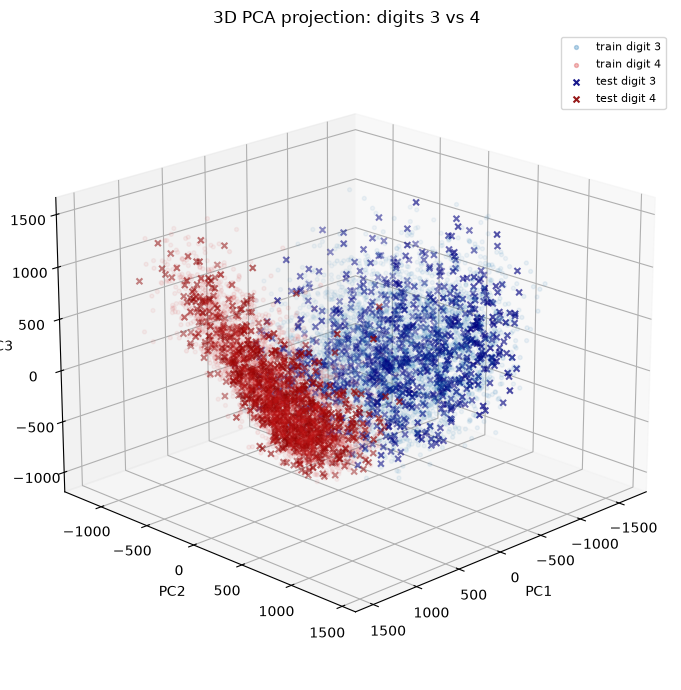

Variance explained by PC1, PC2, PC3: [0.1705 0.0711 0.0577]
Cumulative (3 components): 0.2993


In [21]:
Z_train_34_3d = pca_project(X_train_34, mean_34, P3_34)
Z_test_34_3d = pca_project(X_test_34, mean_34, P3_34)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
for cls, name, color in [(0, 'digit 3', 'tab:blue'), (1, 'digit 4', 'tab:red')]:
    mask = y_train_34 == cls
    ax.scatter(Z_train_34_3d[mask, 0], Z_train_34_3d[mask, 1], Z_train_34_3d[mask, 2],
               s=8, alpha=0.3, color=color, label=f'train {name}')
for cls, name, color in [(0, 'digit 3', 'navy'), (1, 'digit 4', 'darkred')]:
    mask = y_test_34 == cls
    ax.scatter(Z_test_34_3d[mask, 0], Z_test_34_3d[mask, 1], Z_test_34_3d[mask, 2],
               s=18, alpha=0.9, color=color, marker='x', label=f'test {name}')

ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('3D PCA projection: digits 3 vs 4')
ax.view_init(elev=20, azim=45)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

var_ratio = S_34 ** 2 / np.sum(S_34 ** 2)
print("Variance explained by PC1, PC2, PC3:", np.round(var_ratio[:3], 4))
print("Cumulative (3 components):", round(var_ratio[:3].sum(), 4))

---
## Exercise 6: Classification After PCA: Linear Classifier and Centroid Classifier

### Step 1: PCA Projection

We reuse exactly the objects built in Exercise 5 for digits $\{3,4\}$: `mean_34`, `P2_34`,
`Z_train_34` and `Z_test_34`, where by construction
$Z_{\text{test}} = (X_{\text{test}} - c(X_{\text{train}}))P$, as required by the assignment.

In [22]:
print("Z_train_34:", Z_train_34.shape, "  Z_test_34:", Z_test_34.shape)
print("Column means of Z_train (they must be ~0, since the data were centered):",
      np.round(Z_train_34.mean(axis=0), 6))

Z_train_34: (6739, 2)   Z_test_34: (1684, 2)
Column means of Z_train (they must be ~0, since the data were centered): [-0.  0.]


### Step 2: Fit a linear classifier

The assignment specifies the model $f_\Theta(z)=\sigma(\Theta^T z)$ with $z\in\mathbb{R}^2$, i.e. **two
parameters and no intercept**, trained with the binary cross-entropy loss by SGD. We implement exactly
that.

One numerical remark. The PCA scores have magnitudes of order $10^2\!-\!10^3$ (they scale with the
$\sigma_i$), so the gradient of the loss is correspondingly large and a fixed learning rate would make
plain SGD oscillate instead of converging. We therefore optimise on rescaled scores $Z/\text{std}(Z)$
and convert $\Theta$ back to the original coordinates afterwards. Since $Z_{\text{train}}$ already has
**exactly zero mean** (it comes from centered data), dividing by the standard deviation is a pure
rescaling: it does not shift the origin and therefore does **not** introduce a hidden intercept. The
model actually fitted and evaluated is still $\sigma(\Theta^T z)$ with a boundary through the origin.

In [23]:
def sigmoid(z):
    """Numerically stable sigmoid (no overflow for large |z|)."""
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    exp_z = np.exp(z[~pos])
    out[~pos] = exp_z / (1.0 + exp_z)
    return out


def bce_loss(theta, Z_, y_):
    """Binary cross-entropy."""
    p = sigmoid(Z_ @ theta)
    eps = 1e-12
    return -np.mean(y_ * np.log(p + eps) + (1 - y_) * np.log(1 - p + eps))


def bce_grad(theta, Z_, y_):
    """Gradient of the BCE loss w.r.t. theta."""
    p = sigmoid(Z_ @ theta)
    return (Z_.T @ (p - y_)) / Z_.shape[0]


def sgd_logreg(Z_, y_, theta0, eta=0.5, batch_size=32, n_epochs=200, seed=0):
    """Mini-batch SGD. The full-training-set loss is recorded once per epoch
    (not once per batch) so that monitoring convergence stays cheap."""
    rng_ = np.random.default_rng(seed)
    theta = theta0.copy()
    N_ = Z_.shape[0]
    losses = []
    for _ in range(n_epochs):
        idx = rng_.permutation(N_)
        for start in range(0, N_, batch_size):
            b = idx[start:start + batch_size]
            theta = theta - eta * bce_grad(theta, Z_[b], y_[b])
        losses.append(bce_loss(theta, Z_, y_))
    return theta, losses

In [24]:
# fit on rescaled scores, then map Theta back to the original PCA coordinates
sd_34 = Z_train_34.std(axis=0)

theta_std_34, losses_34 = sgd_logreg(Z_train_34 / sd_34, y_train_34,
                                     theta0=np.zeros(2), eta=0.5,
                                     batch_size=32, n_epochs=200, seed=6)
theta_lin_34 = theta_std_34 / sd_34

print("Theta (w1, w2) in the original PCA coordinates:", theta_lin_34)
print(f"BCE loss: {losses_34[0]:.4f} (after 1 epoch)  ->  {losses_34[-1]:.4f} (after 200 epochs)")

Theta (w1, w2) in the original PCA coordinates: [ 0.00933152 -0.0007377 ]
BCE loss: 0.0930 (after 1 epoch)  ->  0.0834 (after 200 epochs)


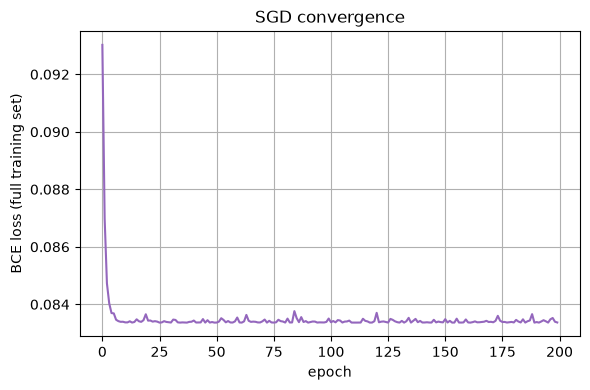

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(losses_34, color='tab:purple')
ax.set_xlabel('epoch')
ax.set_ylabel('BCE loss (full training set)')
ax.set_title('SGD convergence')
plt.tight_layout()
plt.show()

**Plot the PCA-reduced training data together with the decision boundary** $\Theta^T z = 0$, i.e. the
line $\theta_1 z_1 + \theta_2 z_2 = 0$, which necessarily passes through the origin.

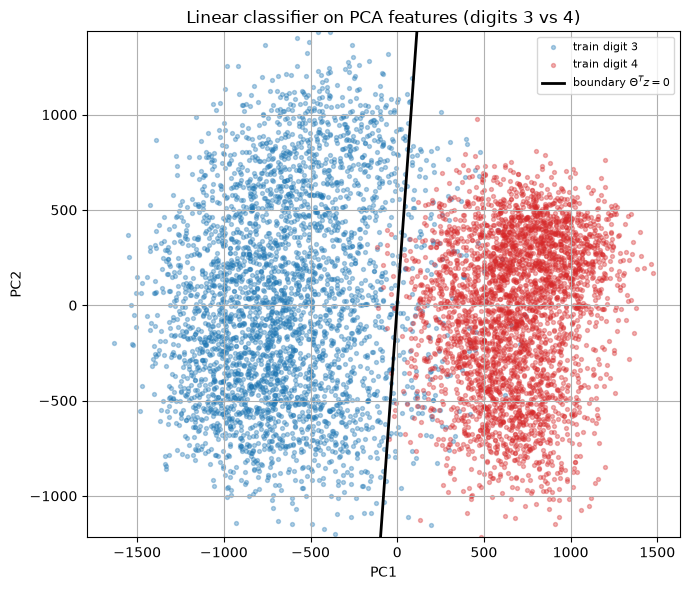

In [26]:
z1_range = np.linspace(Z_train_34[:, 0].min() - 1, Z_train_34[:, 0].max() + 1, 100)
z2_boundary = -(theta_lin_34[0] / theta_lin_34[1]) * z1_range

fig, ax = plt.subplots(figsize=(7, 6))
for cls, name, color in [(0, 'digit 3', 'tab:blue'), (1, 'digit 4', 'tab:red')]:
    mask = y_train_34 == cls
    ax.scatter(Z_train_34[mask, 0], Z_train_34[mask, 1], s=8, alpha=0.35, color=color,
               label=f'train {name}')
ax.plot(z1_range, z2_boundary, 'k-', lw=2, label=r'boundary $\Theta^T z = 0$')

ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_ylim(Z_train_34[:, 1].min() - 1, Z_train_34[:, 1].max() + 1)
ax.set_title('Linear classifier on PCA features (digits 3 vs 4)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Test-set metrics for the linear classifier**: accuracy, precision, recall and confusion matrix.

In [27]:
def confusion_matrix_counts(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    return TP, FP, FN, TN


def eval_predictions(y_true, y_pred):
    TP, FP, FN, TN = confusion_matrix_counts(y_true, y_pred)
    return {'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
            'accuracy': (TP + TN) / (TP + FP + FN + TN),
            'precision': TP / (TP + FP) if (TP + FP) > 0 else 0.0,
            'recall': TP / (TP + FN) if (TP + FN) > 0 else 0.0}


def print_metrics(name, mtr):
    print(f"{name}:")
    for k, v in mtr.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


def plot_confusion(y_true, y_pred, labels, title):
    """Confusion matrix laid out as [[TN, FP], [FN, TP]]."""
    TP, FP, FN, TN = confusion_matrix_counts(y_true, y_pred)
    cm = np.array([[TN, FP], [FN, TP]])

    fig, ax = plt.subplots(figsize=(4.2, 3.8))
    ax.imshow(cm, cmap='Blues')
    ax.grid(False)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=13,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels([f'pred {labels[0]}', f'pred {labels[1]}'])
    ax.set_yticks([0, 1]); ax.set_yticklabels([f'true {labels[0]}', f'true {labels[1]}'])
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

Linear classifier (3 vs 4), test set:
  TP: 796
  FP: 41
  FN: 7
  TN: 840
  accuracy: 0.9715
  precision: 0.9510
  recall: 0.9913


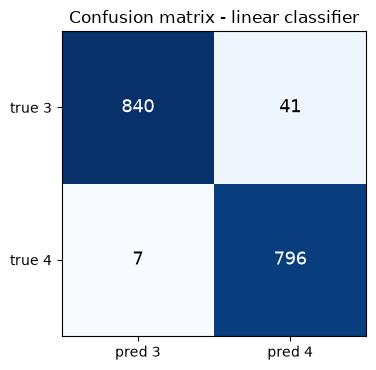

In [28]:
p_test_lin_34 = sigmoid(Z_test_34 @ theta_lin_34)
pred_lin_34 = (p_test_lin_34 >= 0.5).astype(int)

metrics_lin_34 = eval_predictions(y_test_34, pred_lin_34)
print_metrics("Linear classifier (3 vs 4), test set", metrics_lin_34)
plot_confusion(y_test_34, pred_lin_34, (3, 4), 'Confusion matrix - linear classifier')

### Step 3: PCA-Centroid Classifier (Nearest-Centroid in PCA Space)

**1. Class centroids in PCA space.**

centroid of digit 3: [-645.58292844   33.18743699]
centroid of digit 4: [685.27768788 -35.22802275]


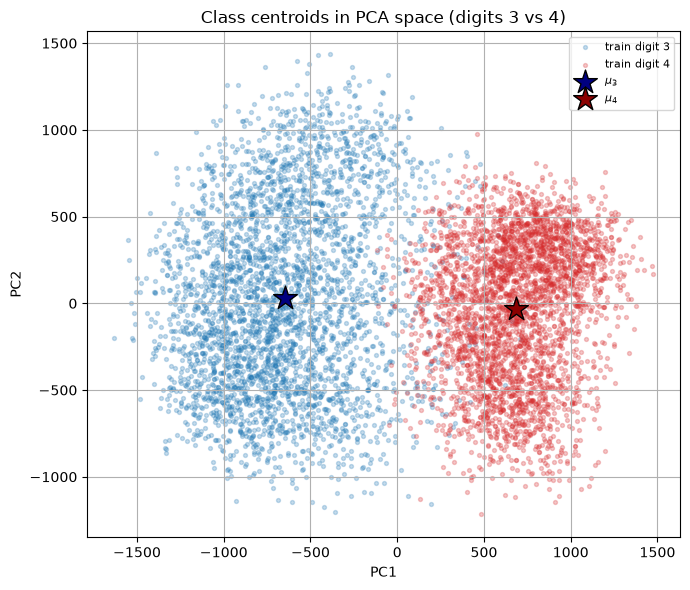

In [29]:
mu3_34 = Z_train_34[y_train_34 == 0].mean(axis=0)
mu4_34 = Z_train_34[y_train_34 == 1].mean(axis=0)
print("centroid of digit 3:", mu3_34)
print("centroid of digit 4:", mu4_34)

fig, ax = plt.subplots(figsize=(7, 6))
for cls, name, color in [(0, 'digit 3', 'tab:blue'), (1, 'digit 4', 'tab:red')]:
    mask = y_train_34 == cls
    ax.scatter(Z_train_34[mask, 0], Z_train_34[mask, 1], s=8, alpha=0.25, color=color,
               label=f'train {name}')
ax.scatter(*mu3_34, color='navy', marker='*', s=320, edgecolor='black', zorder=5, label=r'$\mu_3$')
ax.scatter(*mu4_34, color='darkred', marker='*', s=320, edgecolor='black', zorder=5, label=r'$\mu_4$')

ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Class centroids in PCA space (digits 3 vs 4)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**2. Classify each test point by the nearest centroid**, after projecting it as
$z=(x-c(X_{\text{train}}))P$ -- which is exactly how `Z_test_34` was built.

Centroid classifier (3 vs 4), test set:
  TP: 794
  FP: 38
  FN: 9
  TN: 843
  accuracy: 0.9721
  precision: 0.9543
  recall: 0.9888


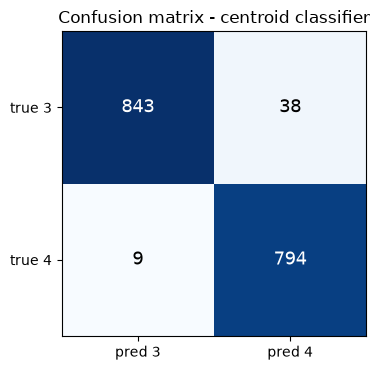

In [30]:
def centroid_classify(Z_, mu0, mu1):
    """Assign each row of Z_ to the closest centroid: 1 if closer to mu1, else 0."""
    d0 = np.linalg.norm(Z_ - mu0, axis=1)
    d1 = np.linalg.norm(Z_ - mu1, axis=1)
    return (d1 < d0).astype(int)


pred_centroid_34 = centroid_classify(Z_test_34, mu3_34, mu4_34)
metrics_centroid_34 = eval_predictions(y_test_34, pred_centroid_34)
print_metrics("Centroid classifier (3 vs 4), test set", metrics_centroid_34)
plot_confusion(y_test_34, pred_centroid_34, (3, 4), 'Confusion matrix - centroid classifier')

**3. Test points coloured by the classification result**, shown two ways: by the predicted class,
and by whether the prediction is correct.

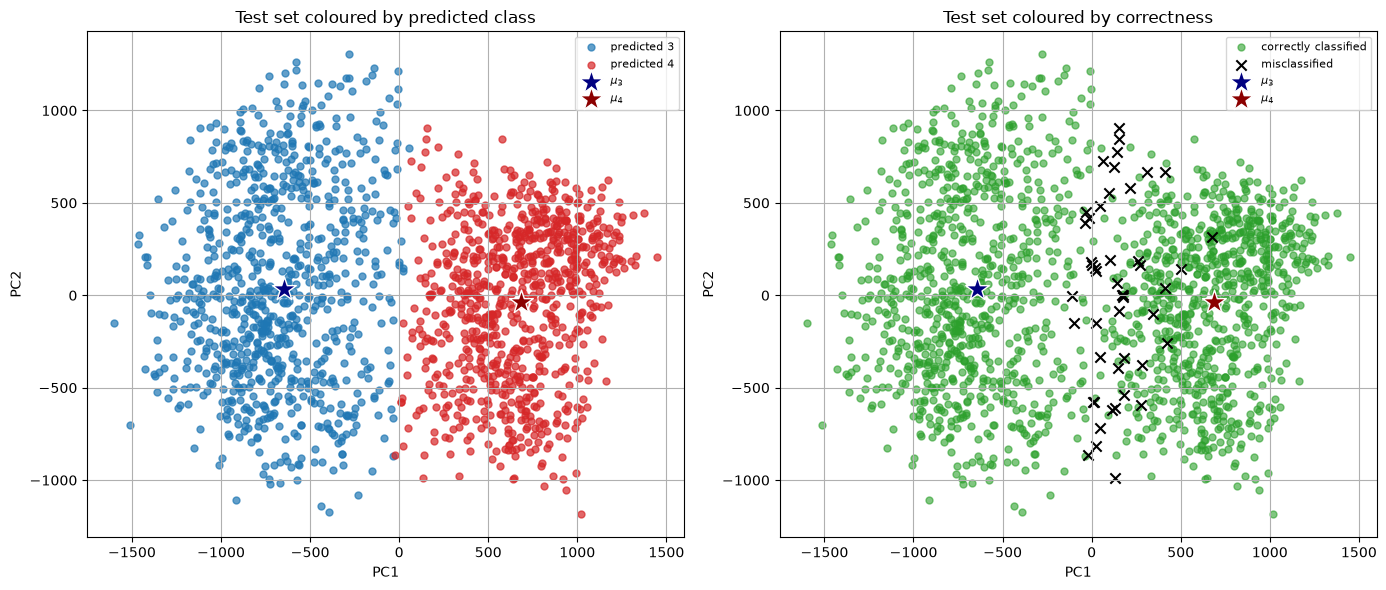

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (a) coloured by predicted class
ax = axes[0]
for cls, name, color in [(0, 'predicted 3', 'tab:blue'), (1, 'predicted 4', 'tab:red')]:
    mask = pred_centroid_34 == cls
    ax.scatter(Z_test_34[mask, 0], Z_test_34[mask, 1], s=25, alpha=0.7, color=color, label=name)
ax.scatter(*mu3_34, color='navy', marker='*', s=320, edgecolor='white', zorder=5, label=r'$\mu_3$')
ax.scatter(*mu4_34, color='darkred', marker='*', s=320, edgecolor='white', zorder=5, label=r'$\mu_4$')
ax.set_title('Test set coloured by predicted class')

# (b) coloured by correctness
ax = axes[1]
correct = pred_centroid_34 == y_test_34
ax.scatter(Z_test_34[correct, 0], Z_test_34[correct, 1], s=25, alpha=0.6,
           color='tab:green', label='correctly classified')
ax.scatter(Z_test_34[~correct, 0], Z_test_34[~correct, 1], s=55, marker='x',
           color='black', label='misclassified')
ax.scatter(*mu3_34, color='navy', marker='*', s=320, edgecolor='white', zorder=5, label=r'$\mu_3$')
ax.scatter(*mu4_34, color='darkred', marker='*', s=320, edgecolor='white', zorder=5, label=r'$\mu_4$')
ax.set_title('Test set coloured by correctness')

for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Step 4: Compare accuracy and error patterns

**1-2. Both classifiers on the same PCA scatterplot**: linear boundary, the two centroids, and the
misclassified test points highlighted in red (circles = errors of the linear model, crosses = errors
of the centroid rule).

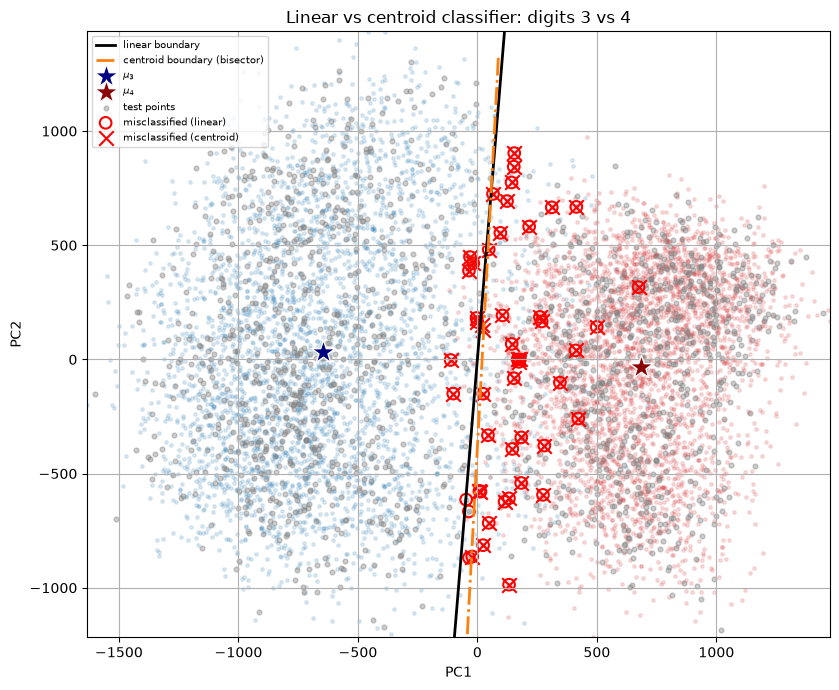

Linear classifier   -> accuracy 0.9715, precision 0.9510, recall 0.9913
Centroid classifier -> accuracy 0.9721, precision 0.9543, recall 0.9888
Test points misclassified by both: 45
Only by the linear model:          3
Only by the centroid rule:         2


In [32]:
pred_lin_wrong = pred_lin_34 != y_test_34
pred_cent_wrong = pred_centroid_34 != y_test_34

fig, ax = plt.subplots(figsize=(8.5, 7))
for cls, name, color in [(0, 'digit 3', 'tab:blue'), (1, 'digit 4', 'tab:red')]:
    mask = y_train_34 == cls
    ax.scatter(Z_train_34[mask, 0], Z_train_34[mask, 1], s=6, alpha=0.15, color=color)

ax.plot(z1_range, z2_boundary, 'k-', lw=2, label='linear boundary')

# the centroid rule is equivalent to the perpendicular bisector of [mu_3, mu_4]
mid = (mu3_34 + mu4_34) / 2
direction = mu4_34 - mu3_34
perp = np.array([-direction[1], direction[0]])
t = np.linspace(-1, 1, 100)
bisector = mid[:, None] + perp[:, None] * t
ax.plot(bisector[0], bisector[1], color='tab:orange', ls='-.', lw=2,
        label='centroid boundary (bisector)')

ax.scatter(*mu3_34, color='navy', marker='*', s=320, edgecolor='white', zorder=6, label=r'$\mu_3$')
ax.scatter(*mu4_34, color='darkred', marker='*', s=320, edgecolor='white', zorder=6, label=r'$\mu_4$')

ax.scatter(Z_test_34[:, 0], Z_test_34[:, 1], s=12, color='gray', alpha=0.4, label='test points')
ax.scatter(Z_test_34[pred_lin_wrong, 0], Z_test_34[pred_lin_wrong, 1], s=70, facecolors='none',
           edgecolors='red', linewidths=1.5, label='misclassified (linear)')
ax.scatter(Z_test_34[pred_cent_wrong, 0], Z_test_34[pred_cent_wrong, 1], s=110, marker='x',
           color='red', linewidths=1.5, label='misclassified (centroid)')

ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_xlim(Z_train_34[:, 0].min() - 1, Z_train_34[:, 0].max() + 1)
ax.set_ylim(Z_train_34[:, 1].min() - 1, Z_train_34[:, 1].max() + 1)
ax.set_title('Linear vs centroid classifier: digits 3 vs 4')
ax.legend(fontsize=7, loc='upper left')
plt.tight_layout()
plt.show()

print(f"Linear classifier   -> accuracy {metrics_lin_34['accuracy']:.4f}, "
      f"precision {metrics_lin_34['precision']:.4f}, recall {metrics_lin_34['recall']:.4f}")
print(f"Centroid classifier -> accuracy {metrics_centroid_34['accuracy']:.4f}, "
      f"precision {metrics_centroid_34['precision']:.4f}, recall {metrics_centroid_34['recall']:.4f}")
print(f"Test points misclassified by both: {np.sum(pred_lin_wrong & pred_cent_wrong)}")
print(f"Only by the linear model:          {np.sum(pred_lin_wrong & ~pred_cent_wrong)}")
print(f"Only by the centroid rule:         {np.sum(~pred_lin_wrong & pred_cent_wrong)}")

**3. Repeat for the digit pairs (1,7), (5,8) and (2,3).**

To compare cluster geometry across pairs we report a **dimensionless** separation index

$$\rho = \frac{\|\mu_1-\mu_0\|}{\sqrt{\tfrac12\big(\operatorname{tr}\widehat\Sigma_0+\operatorname{tr}\widehat\Sigma_1\big)}},$$

i.e. the distance between centroids divided by the average within-class spread. The raw centroid
distance alone would be misleading, because every pair has its own PCA basis fitted on different data,
so the axes are not on a common scale and the distances are not directly comparable across pairs.

In [33]:
def run_pca_classifiers(df, digit0, digit1, k=2, seed=7):
    """Full pipeline for one digit pair: PCA -> logistic regression (SGD) + nearest centroid."""
    X_tr, y_tr, X_te, y_te = load_digit_pair(df, digit0, digit1, seed=seed)

    mean_, P_, _ = pca_fit(X_tr, k)
    Z_tr, Z_te = pca_project(X_tr, mean_, P_), pca_project(X_te, mean_, P_)

    # linear classifier: Theta in R^k, no intercept (as specified)
    sd_ = Z_tr.std(axis=0)
    theta_s_, losses_ = sgd_logreg(Z_tr / sd_, y_tr, theta0=np.zeros(k),
                                   eta=0.5, batch_size=32, n_epochs=200, seed=seed)
    theta_ = theta_s_ / sd_
    pred_lin_ = (sigmoid(Z_te @ theta_) >= 0.5).astype(int)

    # nearest-centroid classifier
    mu0_, mu1_ = Z_tr[y_tr == 0].mean(axis=0), Z_tr[y_tr == 1].mean(axis=0)
    pred_cent_ = centroid_classify(Z_te, mu0_, mu1_)

    # dimensionless separation index
    spread = np.sqrt(0.5 * (Z_tr[y_tr == 0].var(axis=0).sum() + Z_tr[y_tr == 1].var(axis=0).sum()))
    sep_ratio = np.linalg.norm(mu1_ - mu0_) / spread

    return {'digits': (digit0, digit1), 'Z_train': Z_tr, 'y_train': y_tr,
            'Z_test': Z_te, 'y_test': y_te, 'theta': theta_, 'losses': losses_,
            'mu0': mu0_, 'mu1': mu1_, 'sep_ratio': sep_ratio,
            'metrics_lin': eval_predictions(y_te, pred_lin_),
            'metrics_cent': eval_predictions(y_te, pred_cent_),
            'lin_wrong': pred_lin_ != y_te, 'cent_wrong': pred_cent_ != y_te}


pairs = [(3, 4), (1, 7), (5, 8), (2, 3)]
results = {p: run_pca_classifiers(df_mnist, *p) for p in pairs}

print(f"{'pair':>8s} {'sep. index':>11s} {'linear acc':>11s} {'centroid acc':>13s}")
for p in pairs:
    r = results[p]
    print(f"{str(p):>8s} {r['sep_ratio']:>11.3f} "
          f"{r['metrics_lin']['accuracy']:>11.4f} {r['metrics_cent']['accuracy']:>13.4f}")

    pair  sep. index  linear acc  centroid acc
  (3, 4)       2.291      0.9709        0.9721
  (1, 7)       2.120      0.9686        0.9631
  (5, 8)       0.778      0.7664        0.7645
  (2, 3)       1.651      0.9097        0.9067


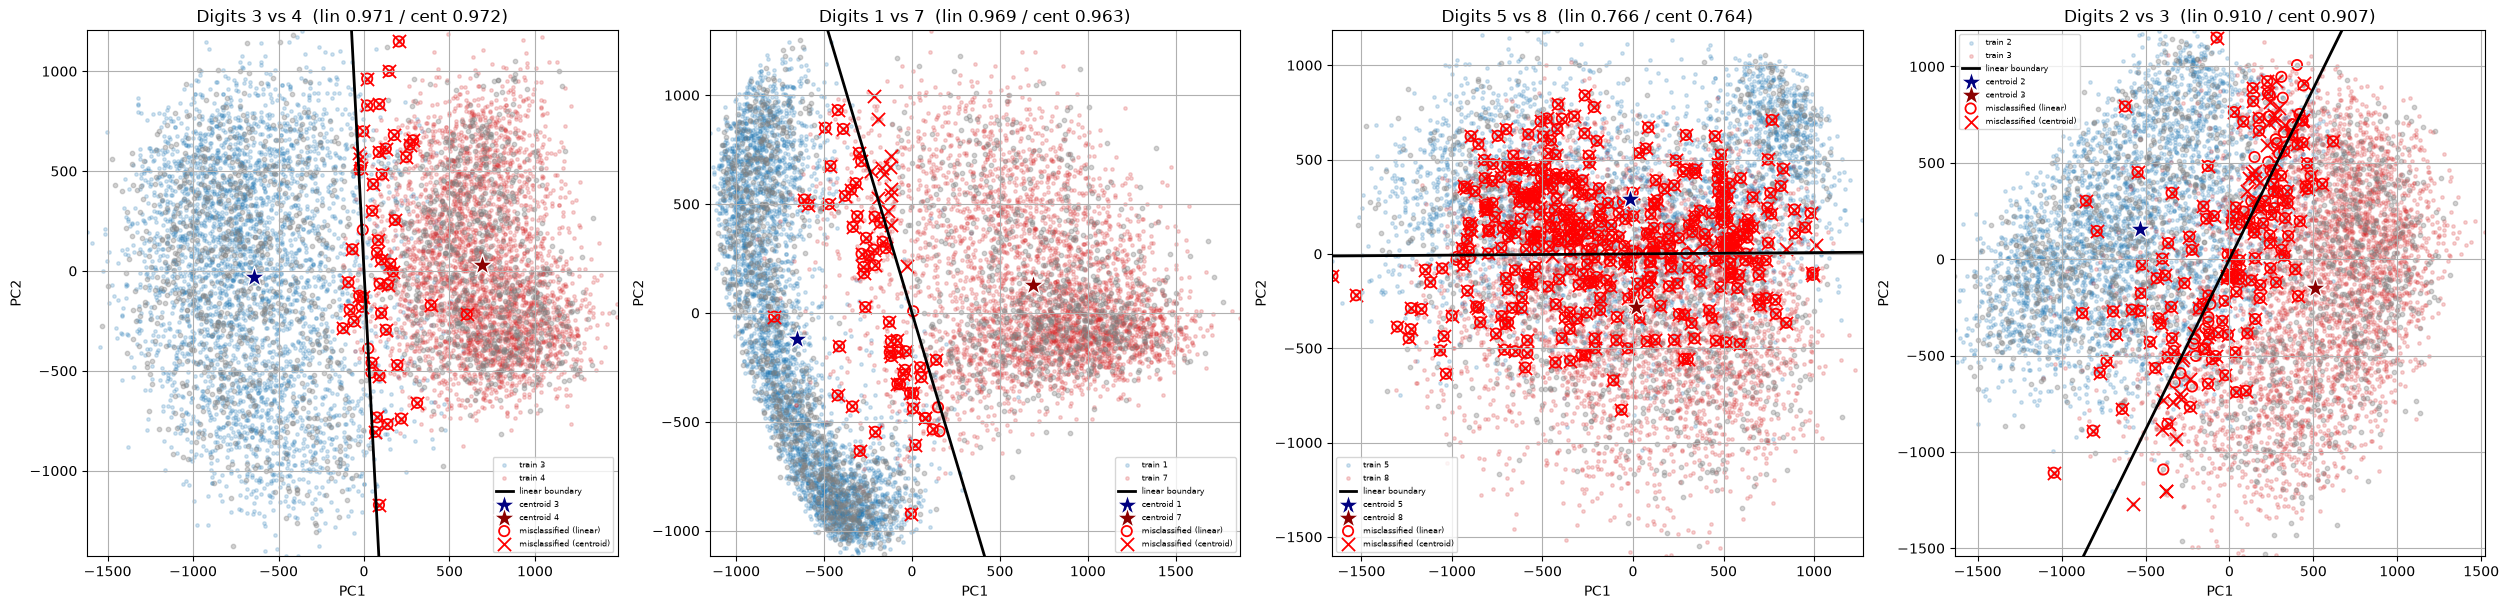

In [34]:
fig, axes = plt.subplots(1, len(pairs), figsize=(6.3 * len(pairs), 6.2))

for ax, p in zip(axes, pairs):
    r = results[p]
    d0, d1 = p

    for cls, d, color in [(0, d0, 'tab:blue'), (1, d1, 'tab:red')]:
        mask = r['y_train'] == cls
        ax.scatter(r['Z_train'][mask, 0], r['Z_train'][mask, 1], s=6, alpha=0.2, color=color,
                   label=f'train {d}')

    th = r['theta']
    z1r = np.linspace(r['Z_train'][:, 0].min() - 1, r['Z_train'][:, 0].max() + 1, 100)
    ax.plot(z1r, -(th[0] / th[1]) * z1r, 'k-', lw=2, label='linear boundary')

    ax.scatter(*r['mu0'], color='navy', marker='*', s=260, edgecolor='white', zorder=6,
               label=f'centroid {d0}')
    ax.scatter(*r['mu1'], color='darkred', marker='*', s=260, edgecolor='white', zorder=6,
               label=f'centroid {d1}')

    ax.scatter(r['Z_test'][:, 0], r['Z_test'][:, 1], s=10, color='gray', alpha=0.35)
    ax.scatter(r['Z_test'][r['lin_wrong'], 0], r['Z_test'][r['lin_wrong'], 1], s=55,
               facecolors='none', edgecolors='red', linewidths=1.3, label='misclassified (linear)')
    ax.scatter(r['Z_test'][r['cent_wrong'], 0], r['Z_test'][r['cent_wrong'], 1], s=90,
               marker='x', color='red', linewidths=1.3, label='misclassified (centroid)')

    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_xlim(r['Z_train'][:, 0].min() - 1, r['Z_train'][:, 0].max() + 1)
    ax.set_ylim(r['Z_train'][:, 1].min() - 1, r['Z_train'][:, 1].max() + 1)
    ax.set_title(f"Digits {d0} vs {d1}  (lin {r['metrics_lin']['accuracy']:.3f} / "
                 f"cent {r['metrics_cent']['accuracy']:.3f})")
    ax.legend(fontsize=6, loc='best')

plt.tight_layout()
plt.show()

Finally, to check the interpretation given below -- that the difficulty of the hard pairs comes from
the **projection** discarding the relevant information, not from the classifiers -- we rerun the worst
pair (5 vs 8) keeping more principal components.

In [35]:
print(f"{'k':>4s} {'linear acc':>11s} {'centroid acc':>13s}")
for k in [2, 5, 10, 20, 50]:
    r = run_pca_classifiers(df_mnist, 5, 8, k=k)
    print(f"{k:>4d} {r['metrics_lin']['accuracy']:>11.4f} {r['metrics_cent']['accuracy']:>13.4f}")

   k  linear acc  centroid acc
   2      0.7664        0.7645
   5      0.9249        0.9223
  10      0.9249        0.9268
  20      0.9402        0.9293
  50      0.9535        0.9313


**Comments.**

**Linear classifier vs centroid classifier.** On digits 3 vs 4 the two methods reach very similar
accuracy, and their errors fall in the same narrow strip between the clusters. That is not a
coincidence: both produce a *linear* decision boundary, so they can only differ in its orientation and
position. The centroid rule assigns $z$ to the nearest $\mu_c$, which is equivalent to the
**perpendicular bisector** of the segment $[\mu_0,\mu_1]$ -- a boundary fully determined by two class
means, with no free parameters. It is fast, needs no optimisation, and is very robust when the classes
are compact and roughly symmetric, exactly the situation for 3 vs 4. Its weakness is rigidity: it
ignores the shape, spread and correlation structure of each cluster, so when the classes have unequal
variances or elongated, non-symmetric shapes, the bisector is placed sub-optimally.

Logistic regression instead fits the boundary **discriminatively**, moving it to minimise the
cross-entropy on the training data, so it can adapt to asymmetric clusters and typically has a slight
edge. In this setup it also carries a specific constraint: without an intercept, the boundary is forced
through the origin of the PCA plane. That is harmless here, because the PCA scores are centered and the
two classes sit on roughly opposite sides of the origin, but for a strongly unbalanced pair it would be
a real limitation.

**How class similarity influences the results.** The table shows a clear monotone relationship between
the separation index $\rho$ and accuracy. Pairs of structurally distinct digits (1 vs 7, 3 vs 4) have
well-separated centroids relative to the within-class spread, compact clusters, and high accuracy for
both classifiers. Pairs of visually similar digits (5 vs 8, and to a lesser extent 2 vs 3) share curved
strokes and comparable ink distribution, so their centroids are close relative to the spread, the point
clouds overlap heavily, and accuracy drops sharply. The errors are not scattered at random: they
concentrate in the overlap region straddling the boundary, precisely where the two clusters interpenetrate.

The underlying reason is the one already identified in Exercise 5: the difficulty of the task in this
plane is governed by how well the *unsupervised* top-2 variance directions happen to align with the
distinction between that particular pair of classes. When they do not, the information needed to
separate the digits has been discarded by the projection itself, and **no** classifier operating on
those two components can recover it -- neither of the two classifiers is "at fault". The table just
above confirms this directly: keeping more principal components raises the accuracy on 5 vs 8
substantially, with both classifiers improving together, which is the signature of a
*representation* bottleneck rather than a *model* bottleneck. The alternative remedy is a supervised
projection such as LDA, which chooses directions maximising class separation rather than total variance.

---
## Appendix: effect of the intercept

The assignment prescribes $f_\Theta(z)=\sigma(\Theta^Tz)$ with $z\in\mathbb{R}^2$, hence a boundary
through the origin, and that is the model used above. As a check that this constraint is not what
limits performance, we refit the same classifier with an added bias term, $\sigma(b+w^Tz)$, and compare.

In [36]:
# augmented design matrices [1, z1, z2]
Zt_aug = np.column_stack([np.ones(len(Z_train_34)), Z_train_34 / sd_34])
Zte_aug = np.column_stack([np.ones(len(Z_test_34)), Z_test_34 / sd_34])

theta_bias_s, _ = sgd_logreg(Zt_aug, y_train_34, theta0=np.zeros(3),
                             eta=0.5, batch_size=32, n_epochs=200, seed=6)
pred_bias = (sigmoid(Zte_aug @ theta_bias_s) >= 0.5).astype(int)
metrics_bias = eval_predictions(y_test_34, pred_bias)

print(f"No intercept (as required): accuracy {metrics_lin_34['accuracy']:.4f}")
print(f"With intercept:             accuracy {metrics_bias['accuracy']:.4f}")

b, w = theta_bias_s[0], theta_bias_s[1:]
print(f"\nFitted intercept (on rescaled scores): b = {b:.4f}")
print(f"Weight norm:                          ||w|| = {np.linalg.norm(w):.4f}")
print(f"Ratio |b| / ||w||:                    {abs(b) / np.linalg.norm(w):.4f}")
print("\nThe smaller this ratio, the closer the fitted boundary passes to the origin, i.e.")
print("the less the no-intercept constraint costs. This is expected here: the PCA scores")
print("are centered and the two classes lie nearly symmetrically about the origin.")

No intercept (as required): accuracy 0.9715
With intercept:             accuracy 0.9757

Fitted intercept (on rescaled scores): b = -1.4323
Weight norm:                          ||w|| = 8.6663
Ratio |b| / ||w||:                    0.1653

The smaller this ratio, the closer the fitted boundary passes to the origin, i.e.
the less the no-intercept constraint costs. This is expected here: the PCA scores
are centered and the two classes lie nearly symmetrically about the origin.
